In [16]:
import pandas as pd
df_clean=pd.read_csv("clean.csv")

In [17]:
if df_clean is not None:
    print("\n--- DataFrame Information (df_clean.info()) ---")
    df_clean.info()


--- DataFrame Information (df_clean.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    12575 non-null  object 
 1   customer_id       12575 non-null  object 
 2   category          12575 non-null  object 
 3   item              12575 non-null  object 
 4   price_per_unit    12575 non-null  float64
 5   quantity          12575 non-null  int64  
 6   total_spent       12575 non-null  float64
 7   payment_method    12575 non-null  object 
 8   location          12575 non-null  object 
 9   transaction_date  12575 non-null  object 
 10  discount_applied  12575 non-null  bool   
 11  year              12575 non-null  int64  
 12  month             12575 non-null  int64  
 13  month_name        12575 non-null  object 
 14  day               12575 non-null  int64  
 15  weekday           12575 non-null  obje

In [18]:
if df_clean is not None:
    print("\n--- Descriptive Statistics (df_clean.describe()) ---")
    display(df_clean.describe())


--- Descriptive Statistics (df_clean.describe()) ---


,price_per_unit,quantity,total_spent,year,month,day,quarter
count,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000,12575.000000
mean,23.381948,5.553956,130.174990,2023.042386,6.366441,15.633002,2.463777
std,10.488257,2.792733,92.438499,0.855581,3.503156,8.803184,1.122568
min,5.000000,1.000000,5.000000,2022.000000,1.000000,1.000000,1.000000
25%,14.000000,3.000000,55.000000,2022.000000,3.000000,8.000000,1.000000
50%,23.000000,6.000000,110.000000,2023.000000,6.000000,15.000000,2.000000
75%,32.000000,8.000000,192.000000,2024.000000,9.000000,23.000000,3.000000
max,41.000000,10.000000,410.000000,2025.000000,12.000000,31.000000,4.000000


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 130,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

PALETTE = ['#1B4F72', '#2E86C1', '#AED6F1', '#117A65', '#1ABC9C',
           '#A9DFBF', '#784212', '#F0B27A']
ACCENT  = '#E74C3C'
DARK    = '#1C2833'

df = pd.read_csv('clean.csv')  # adjust path if needed
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print(f"Shape: {df.shape}")
df.head(3)

Shape: (12575, 17)


,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,discount_applied,year,month,month_name,day,weekday,quarter
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True,2024,4,April,8,Monday,2
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True,2023,7,July,23,Sunday,3
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False,2022,10,October,5,Wednesday,4


In [20]:
# ── 1. Check duplicates ───────────────────────────────────────
print(f"Duplicate rows     : {df.duplicated().sum()}")
print(f"Duplicate txn_ids  : {df['transaction_id'].duplicated().sum()}")

# ── 2. Missing values ─────────────────────────────────────────
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# ── 3. Validate derived columns ───────────────────────────────
df['_calc_total'] = (df['price_per_unit'] * df['quantity']).round(2)
mismatch = (df['total_spent'] != df['_calc_total']).sum()
print(f"\nTotal-spend mismatches (price×qty): {mismatch}")
df.drop(columns=['_calc_total'], inplace=True)

# ── 4. Outlier summary (IQR) ──────────────────────────────────
for col in ['price_per_unit', 'quantity', 'total_spent']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"Outliers in {col:<20}: {n_out}")

# ── 5. Fix dtypes ─────────────────────────────────────────────
df['discount_applied'] = df['discount_applied'].astype(bool)
cat_cols = ['category', 'payment_method', 'location', 'weekday', 'month_name']
for c in cat_cols:
    df[c] = df[c].astype('category')

print("\n✅ Pipeline complete. No critical issues found.")
df.info()

Duplicate rows     : 0
Duplicate txn_ids  : 0

Missing values:
Series([], dtype: int64)

Total-spend mismatches (price×qty): 0
Outliers in price_per_unit      : 0
Outliers in quantity            : 0
Outliers in total_spent         : 56

✅ Pipeline complete. No critical issues found.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    12575 non-null  object        
 1   customer_id       12575 non-null  object        
 2   category          12575 non-null  category      
 3   item              12575 non-null  object        
 4   price_per_unit    12575 non-null  float64       
 5   quantity          12575 non-null  int64         
 6   total_spent       12575 non-null  float64       
 7   payment_method    12575 non-null  category      
 8   location          12575 non-null  category      
 9   transact

In [21]:
summary = df[['price_per_unit', 'quantity', 'total_spent']].describe().T
summary['CV%'] = (summary['std'] / summary['mean'] * 100).round(1)
summary.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'CV%']).format(precision=2)

,count,mean,std,min,25%,50%,75%,max,CV%
price_per_unit,12575.00,23.38,10.49,5.00,14.00,23.00,32.00,41.00,44.90
quantity,12575.00,5.55,2.79,1.00,3.00,6.00,8.00,10.00,50.30
total_spent,12575.00,130.17,92.44,5.00,55.00,110.00,192.00,410.00,71.00


# insights

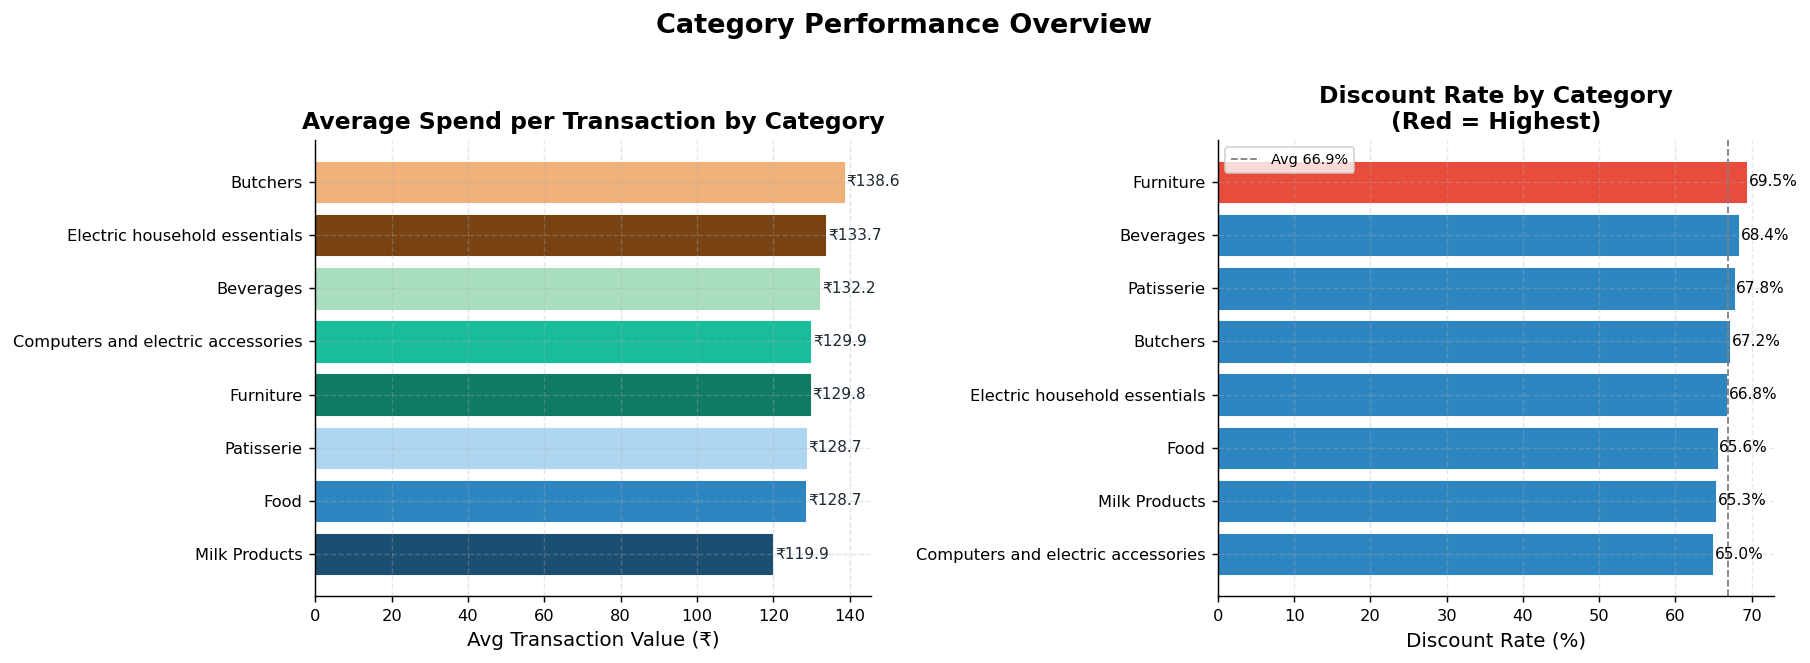

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Category Performance Overview', fontsize=15, fontweight='bold', y=1.01)

# Left: Avg spend by category
cat_spend = df.groupby('category')['total_spent'].mean().sort_values()
bars = axes[0].barh(cat_spend.index, cat_spend.values,
                    color=PALETTE[:len(cat_spend)], edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Avg Transaction Value (₹)')
axes[0].set_title('Average Spend per Transaction by Category')
for bar, val in zip(bars, cat_spend.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'₹{val:.1f}', va='center', fontsize=8.5, color=DARK)

# Right: Discount rate by category
cat_disc = df.groupby('category')['discount_applied'].mean().sort_values() * 100
colors = [ACCENT if v == cat_disc.max() else '#2E86C1' for v in cat_disc.values]
bars2 = axes[1].barh(cat_disc.index, cat_disc.values, color=colors,
                     edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Discount Rate (%)')
axes[1].set_title('Discount Rate by Category\n(Red = Highest)')
axes[1].axvline(cat_disc.mean(), color='gray', linestyle='--', linewidth=1, label=f'Avg {cat_disc.mean():.1f}%')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, cat_disc.values):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('chart1_category_performance.png', bbox_inches='tight', dpi=150)
plt.show()

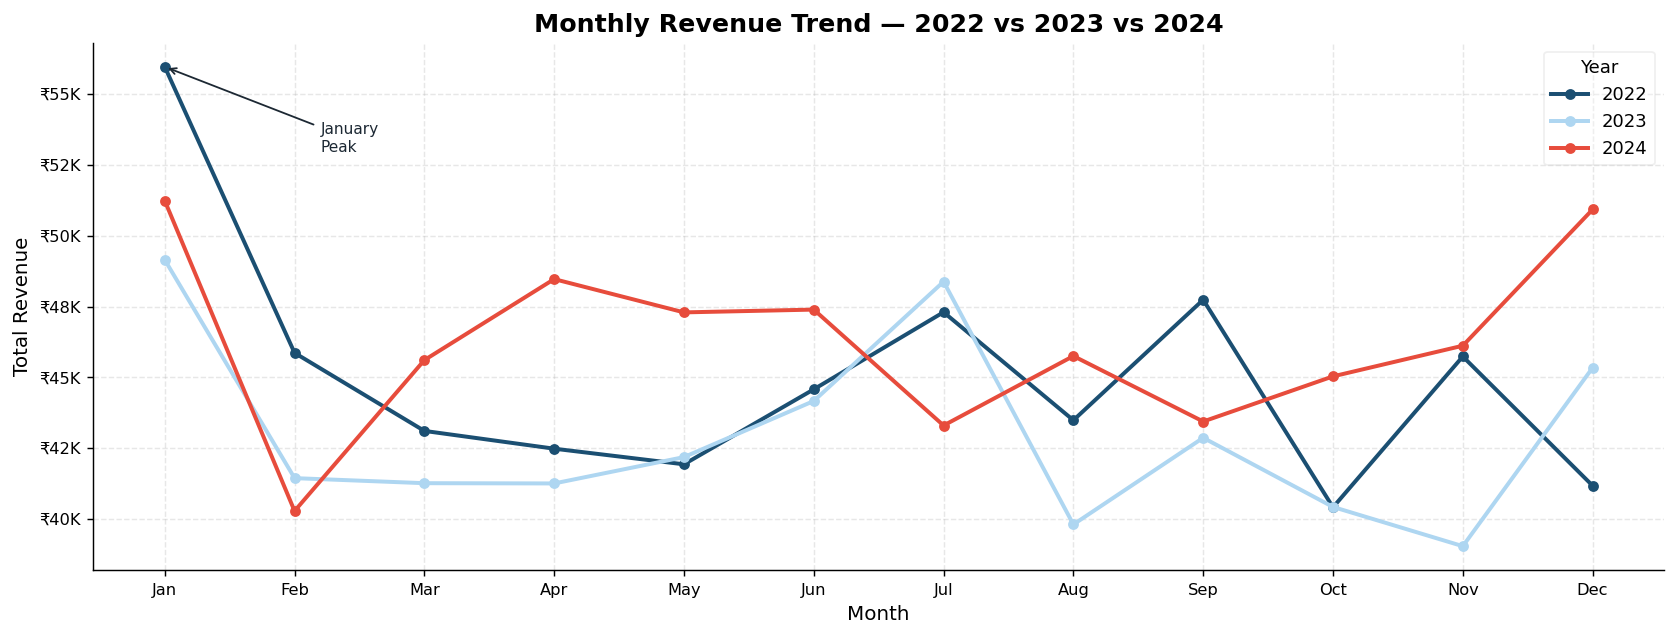

In [23]:
monthly = df[df['year'].isin([2022, 2023, 2024])].groupby(['year', 'month'])['total_spent'].sum().unstack(0)

fig, ax = plt.subplots(figsize=(13, 5))
colors_yr = {'2022': '#1B4F72', '2023': '#AED6F1', '2024': ACCENT}
for yr in [2022, 2023, 2024]:
    ax.plot(monthly.index, monthly[yr], marker='o', linewidth=2.2,
            markersize=5, label=str(yr), color=colors_yr[str(yr)])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax.set_title('Monthly Revenue Trend — 2022 vs 2023 vs 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
ax.legend(title='Year', framealpha=0.3)

# Annotate Jan peak
ax.annotate('January\nPeak', xy=(1, monthly.loc[1, 2022]),
            xytext=(2.2, monthly.loc[1, 2022] - 3000),
            arrowprops=dict(arrowstyle='->', color=DARK),
            fontsize=8.5, color=DARK)

plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', bbox_inches='tight', dpi=150)
plt.show()

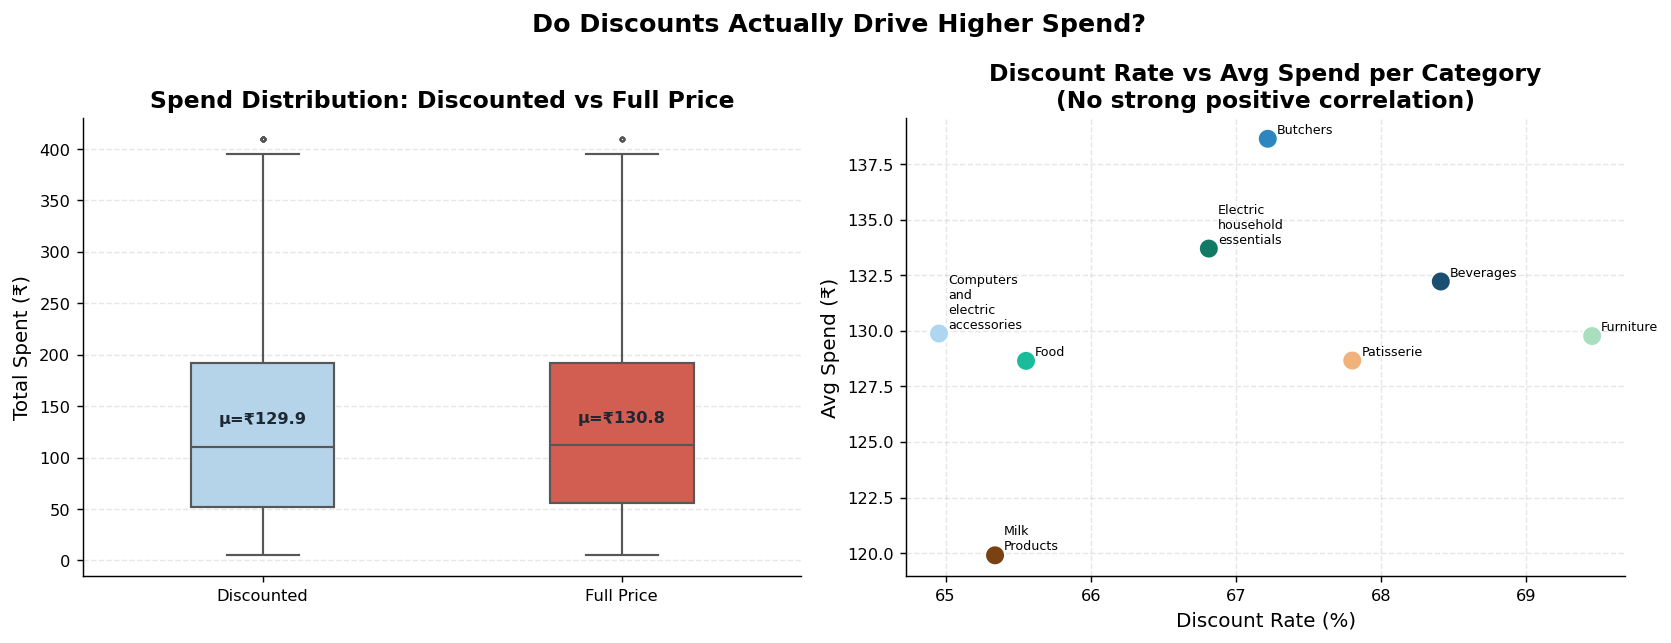

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Do Discounts Actually Drive Higher Spend?', fontsize=14, fontweight='bold')

# Left: Boxplot comparison
disc_labels = {True: 'Discounted', False: 'Full Price'}
df['disc_label'] = df['discount_applied'].map(disc_labels)
sns.boxplot(data=df, x='disc_label', y='total_spent', ax=axes[0],
            palette={'Discounted': '#AED6F1', 'Full Price': ACCENT},
            width=0.4, linewidth=1.2, fliersize=2)
axes[0].set_title('Spend Distribution: Discounted vs Full Price')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Spent (₹)')
means = df.groupby('disc_label')['total_spent'].mean()
for i, (lbl, val) in enumerate(means.items()):
    axes[0].text(i, val + 3, f'μ=₹{val:.1f}', ha='center', fontsize=9,
                 fontweight='bold', color=DARK)

# Right: Discount rate per category vs avg spend scatter
cat_stats = df.groupby('category').agg(
    avg_spend=('total_spent', 'mean'),
    disc_rate=('discount_applied', 'mean')
).reset_index()
cat_stats['disc_rate'] *= 100

sc = axes[1].scatter(cat_stats['disc_rate'], cat_stats['avg_spend'],
                     s=120, c=PALETTE[:len(cat_stats)], zorder=3, edgecolors='white', linewidth=1)
for _, row in cat_stats.iterrows():
    axes[1].annotate(row['category'].replace(' ', '\n'),
                     (row['disc_rate'], row['avg_spend']),
                     textcoords='offset points', xytext=(5, 3), fontsize=7)
axes[1].set_xlabel('Discount Rate (%)')
axes[1].set_ylabel('Avg Spend (₹)')
axes[1].set_title('Discount Rate vs Avg Spend per Category\n(No strong positive correlation)')

plt.tight_layout()
plt.savefig('chart3_discount_impact.png', bbox_inches='tight', dpi=150)
plt.show()

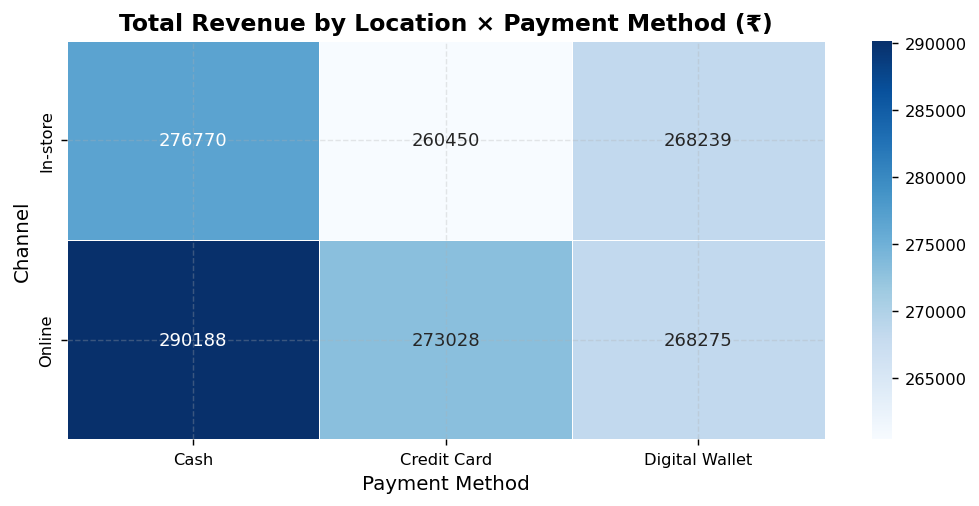


💡 Insight: Cash dominates both channels — notably even in Online, suggesting high COD usage.


In [25]:
pivot = df.groupby(['location', 'payment_method'])['total_spent'].sum().unstack()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 10})
ax.set_title('Total Revenue by Location × Payment Method (₹)', fontsize=13, fontweight='bold')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Channel')
plt.tight_layout()
plt.savefig('chart4_payment_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n💡 Insight: Cash dominates both channels — notably even in Online, suggesting high COD usage.")

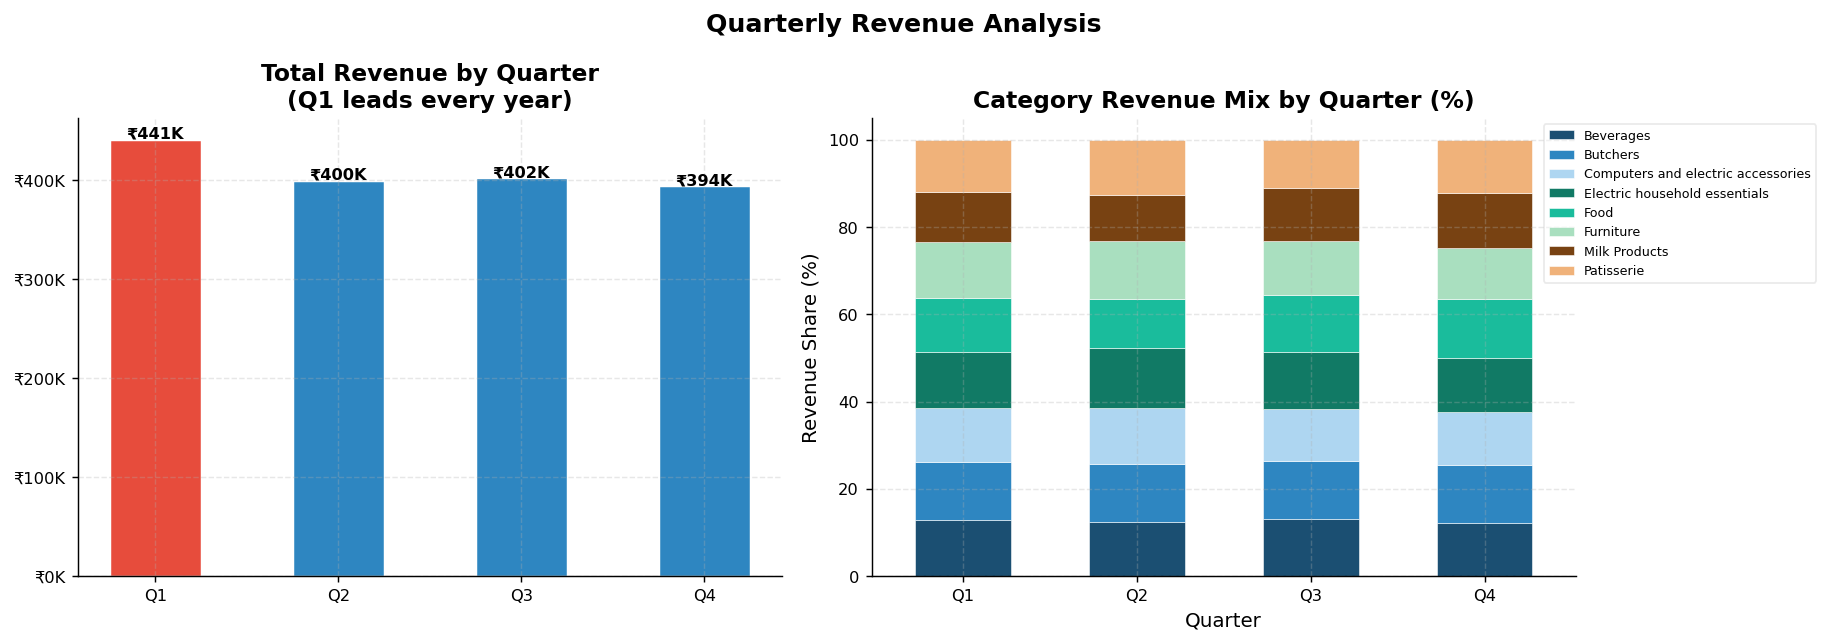

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Quarterly Revenue Analysis', fontsize=14, fontweight='bold')

# Left: Quarterly revenue bar
q_rev = df.groupby('quarter')['total_spent'].sum()
bar_colors = [ACCENT if v == q_rev.max() else '#2E86C1' for v in q_rev.values]
bars = axes[0].bar([f'Q{q}' for q in q_rev.index], q_rev.values,
                   color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
axes[0].set_title('Total Revenue by Quarter\n(Q1 leads every year)')
for bar, val in zip(bars, q_rev.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1500,
                 f'₹{val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')

# Right: Stacked category split by quarter
cat_q = df.groupby(['quarter', 'category'])['total_spent'].sum().unstack().fillna(0)
cat_q_pct = cat_q.div(cat_q.sum(axis=1), axis=0) * 100
cat_q_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=PALETTE, edgecolor='white', linewidth=0.3, width=0.55)
axes[1].set_title('Category Revenue Mix by Quarter (%)')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Revenue Share (%)')
axes[1].set_xticklabels([f'Q{i+1}' for i in range(4)], rotation=0)
axes[1].legend(loc='upper right', fontsize=7, framealpha=0.4,
               bbox_to_anchor=(1.35, 1))

plt.tight_layout()
plt.savefig('chart5_quarterly_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

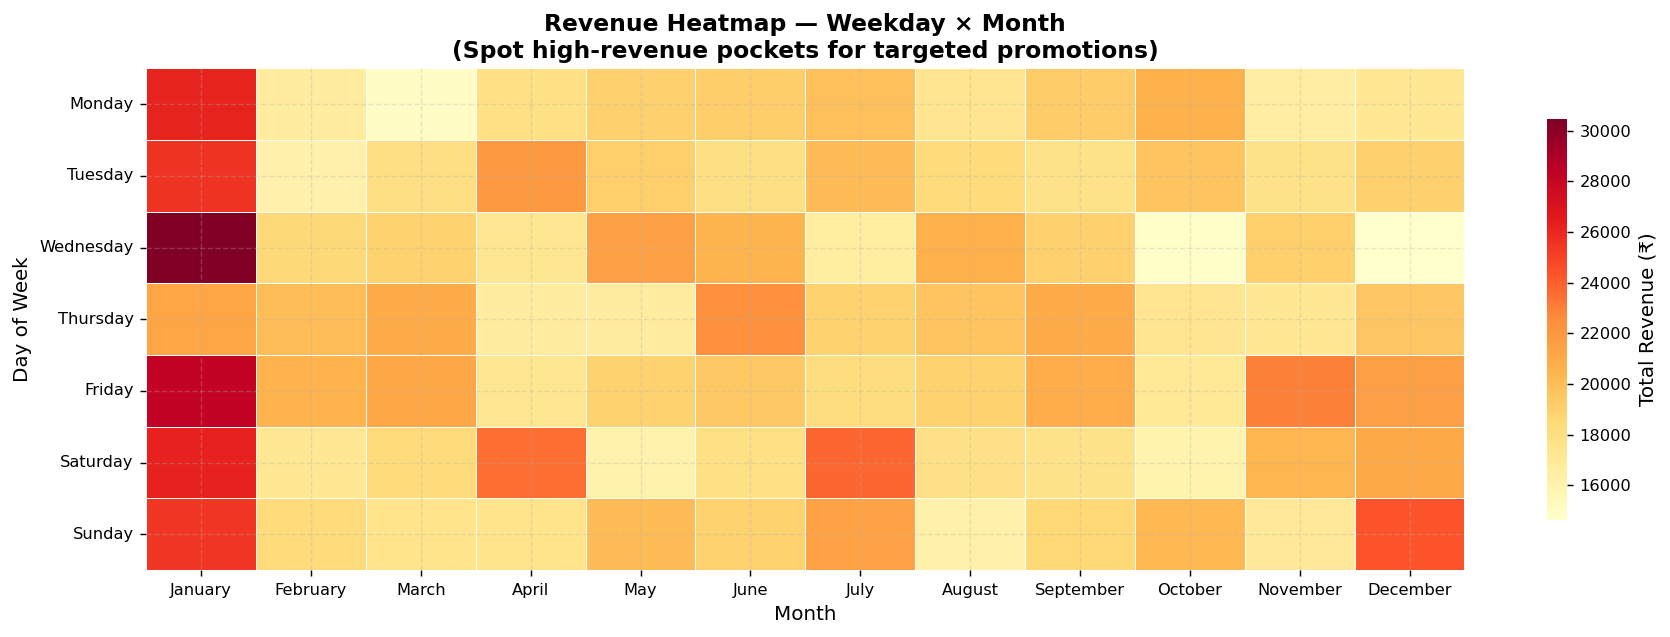

In [27]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

pivot2 = df.groupby(['weekday', 'month_name'])['total_spent'].sum().unstack()
pivot2 = pivot2.reindex(index=day_order, columns=month_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot2, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            ax=ax, fmt='.0f', annot=False,
            cbar_kws={'label': 'Total Revenue (₹)', 'shrink': 0.8})
ax.set_title('Revenue Heatmap — Weekday × Month\n(Spot high-revenue pockets for targeted promotions)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('chart6_weekday_month_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

TOP 10 PRODUCTS WITH HIGHEST REVENUE GROWTH (2023 → 2024)


year,2022,2023,2024,Growth_23_to_24_%
item,,,,
Item_21_PAT,₹175.00,₹52.50,₹175.00,233.3%
Item_25_MILK,₹369.00,₹133.25,₹369.00,176.9%
Item_13_BEV,₹97.75,₹69.00,₹184.00,166.7%
Item_14_MILK,₹142.10,₹85.75,₹214.38,150.0%
Item_10_BUT,₹123.33,₹62.90,₹136.90,117.6%
Item_24_EHE,₹276.50,₹151.42,₹284.40,87.8%
Item_3_BEV,₹45.33,₹25.00,₹46.61,86.4%
Item_10_PAT,₹103.60,₹55.50,₹100.91,81.8%
Item_17_CEA,₹184.15,₹106.33,₹181.25,70.5%


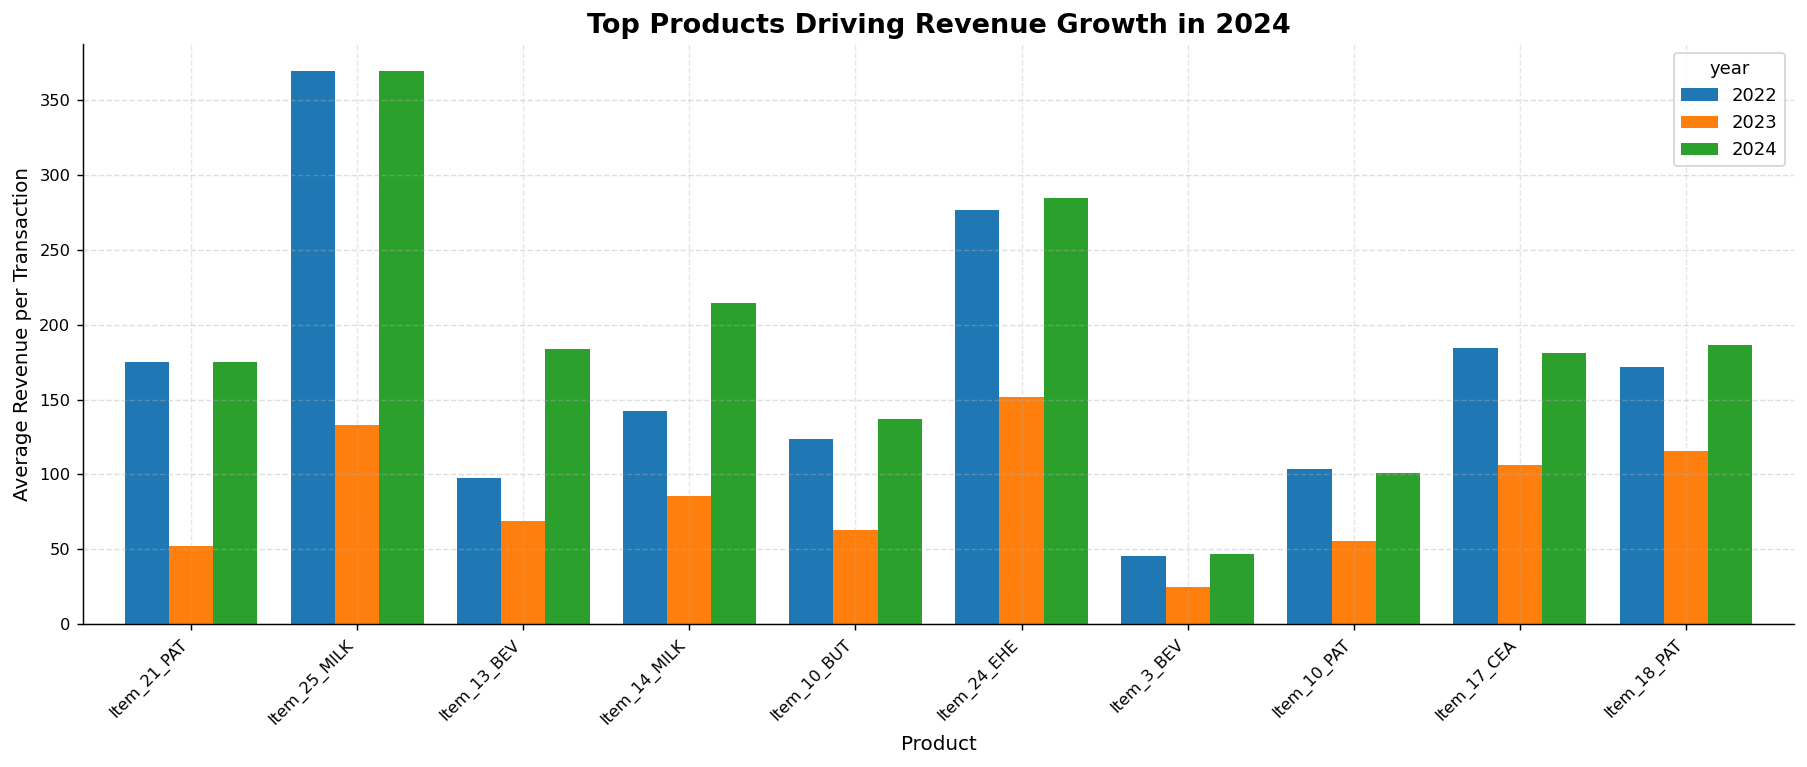



CATEGORY-LEVEL REVENUE GROWTH (2023 → 2024)


year,2022,2023,2024,Growth_23_to_24_%
category,,,,
Beverages,₹132.18,₹124.64,₹137.87,10.6%
Butchers,₹143.34,₹132.04,₹138.78,5.1%
Computers and electric accessories,₹127.95,₹129.56,₹131.10,1.2%
Electric household essentials,₹137.76,₹132.54,₹131.36,-0.9%
Patisserie,₹130.85,₹129.07,₹127.87,-0.9%
Milk Products,₹116.98,₹122.35,₹121.02,-1.1%
Furniture,₹126.92,₹131.89,₹130.33,-1.2%
Food,₹126.74,₹131.98,₹127.69,-3.3%




BUSINESS INSIGHT
The strongest revenue acceleration in 2024 came from the 'Beverages' category, which showed approximately 10.6% growth over 2023.
This suggests that the overall revenue spike in 2024 was likely driven by increased customer demand for higher-value or more frequently purchased products within this category.


In [28]:
# ============================================================
# PRODUCT REVENUE TREND ANALYSIS (2022 vs 2023 vs 2024)
# Finds which products/categories grew the most in 2024
# and helps explain WHY revenue increased
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- FILTER YEARS ----------
temp = df[df['year'].isin([2022, 2023, 2024])].copy()

# ---------- PRODUCT/YEAR REVENUE ----------
product_year = (
    temp.groupby(['item', 'year'])['total_spent']
    .mean()   # average revenue per transaction for each product
    .unstack()
)

# Fill missing values if any
product_year = product_year.fillna(0)

# ---------- CALCULATE GROWTH ----------
# Growth from 2023 -> 2024
product_year['Growth_23_to_24_%'] = (
    ((product_year[2024] - product_year[2023]) / product_year[2023].replace(0, np.nan))
    * 100
)

# Remove inf/nan
product_year = product_year.replace([np.inf, -np.inf], np.nan)
product_year = product_year.dropna(subset=['Growth_23_to_24_%'])

# ---------- TOP GROWING PRODUCTS ----------
top_growth = (
    product_year
    .sort_values('Growth_23_to_24_%', ascending=False)
    .head(10)
)

print("="*70)
print("TOP 10 PRODUCTS WITH HIGHEST REVENUE GROWTH (2023 → 2024)")
print("="*70)

display(
    top_growth[[2022, 2023, 2024, 'Growth_23_to_24_%']]
    .style
    .format({
        2022: '₹{:,.2f}',
        2023: '₹{:,.2f}',
        2024: '₹{:,.2f}',
        'Growth_23_to_24_%': '{:.1f}%'
    })
    .background_gradient(cmap='Greens')
)

# ============================================================
# VISUALIZE TOP GROWING PRODUCTS
# ============================================================

plot_df = top_growth[[2022, 2023, 2024]]

plot_df.plot(
    kind='bar',
    figsize=(14,6),
    width=0.8
)

plt.title('Top Products Driving Revenue Growth in 2024',
          fontsize=15, fontweight='bold')

plt.xlabel('Product')
plt.ylabel('Average Revenue per Transaction')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ============================================================
# CATEGORY-LEVEL CHECK
# Helps identify WHICH categories caused the spike
# ============================================================

category_year = (
    temp.groupby(['category', 'year'])['total_spent']
    .mean()
    .unstack()
)

category_year['Growth_23_to_24_%'] = (
    ((category_year[2024] - category_year[2023]) / category_year[2023])
    * 100
)

print("\n")
print("="*70)
print("CATEGORY-LEVEL REVENUE GROWTH (2023 → 2024)")
print("="*70)

display(
    category_year
    .sort_values('Growth_23_to_24_%', ascending=False)
    .style
    .format({
        2022: '₹{:,.2f}',
        2023: '₹{:,.2f}',
        2024: '₹{:,.2f}',
        'Growth_23_to_24_%': '{:.1f}%'
    })
    .background_gradient(cmap='Oranges')
)

# ============================================================
# BUSINESS INTERPRETATION HELP
# ============================================================

top_cat = category_year['Growth_23_to_24_%'].idxmax()
growth = category_year['Growth_23_to_24_%'].max()

print("\n")
print("="*70)
print("BUSINESS INSIGHT")
print("="*70)

print(
    f"The strongest revenue acceleration in 2024 came from the "
    f"'{top_cat}' category, which showed approximately "
    f"{growth:.1f}% growth over 2023.\n"

    "This suggests that the overall revenue spike in 2024 was likely "
    "driven by increased customer demand for higher-value or more "
    "frequently purchased products within this category."
)

In [29]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['location'], df['payment_method'])
print("Observed Frequencies:")
print(contingency)

chi2, p_val, dof, expected = chi2_contingency(contingency)
print(f"\nChi² statistic : {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value        : {p_val:.4f}")
print()
if p_val < 0.05:
    print("✅ SIGNIFICANT — payment method choice is NOT independent of channel")
    print("   → Customer payment behavior differs between Online and In-store")
else:
    print("❌ NOT SIGNIFICANT — payment method and channel are independent")

Observed Frequencies:
payment_method  Cash  Credit Card  Digital Wallet
location                                         
In-store        2138         2020            2063
Online          2172         2101            2081

Chi² statistic : 0.5319
Degrees of freedom: 2
P-value        : 0.7665

❌ NOT SIGNIFICANT — payment method and channel are independent


In [30]:
from scipy import stats
import pandas as pd
import numpy as np

# ── Test 1: Does discount affect spend? (t-test) ─────────────
disc = df[df['discount_applied'] == True]['total_spent']
full = df[df['discount_applied'] == False]['total_spent']
t_stat, p_val = stats.ttest_ind(disc, full)

print("=" * 55)
print("H1: Are discounts applied strategically?")
print("=" * 55)
print(f"\n[T-test] Mean spend — Discounted: ₹{disc.mean():.2f} | Full: ₹{full.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}  |  P-value: {p_val:.4f}")
print("→", "SIGNIFICANT difference" if p_val < 0.05 else "NO significant difference in spend")

# ── Test 2: Is discount independent of quantity? (Chi-square) ─
df['qty_bucket'] = pd.cut(df['quantity'], bins=[0,3,6,10], labels=['Low','Mid','High'])
ct = pd.crosstab(df['discount_applied'], df['qty_bucket'])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print(f"\n[Chi-square] Discount × Quantity Bucket")
print(ct)
print(f"Chi²: {chi2:.4f}  |  P-value: {p_chi:.4f}  |  DOF: {dof}")
print("→", "Discount IS linked to quantity" if p_chi < 0.05 else "Discount is INDEPENDENT of quantity — applied randomly")

# ── Effect size (Cohen's d) ───────────────────────────────────
pooled_std = np.sqrt((disc.std()**2 + full.std()**2) / 2)
cohens_d = (disc.mean() - full.mean()) / pooled_std
print(f"\nCohen's d (effect size): {cohens_d:.4f}")
print("Interpretation:",
      "Negligible" if abs(cohens_d) < 0.2 else
      "Small" if abs(cohens_d) < 0.5 else "Medium/Large")
print("\n💡 Business conclusion: Discounts are margin leakage, not a sales driver.")

H1: Are discounts applied strategically?

[T-test] Mean spend — Discounted: ₹129.88 | Full: ₹130.78
T-statistic: -0.5117  |  P-value: 0.6089
→ NO significant difference in spend

[Chi-square] Discount × Quantity Bucket
qty_bucket         Low   Mid  High
discount_applied                  
False             1133  1385  1639
True              2402  2735  3281
Chi²: 2.3454  |  P-value: 0.3095  |  DOF: 2
→ Discount is INDEPENDENT of quantity — applied randomly

Cohen's d (effect size): -0.0097
Interpretation: Negligible

💡 Business conclusion: Discounts are margin leakage, not a sales driver.


In [31]:
from scipy.stats import chi2_contingency, chi2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("H4: Are discounts applied differently across categories?")
print("=" * 60)

# ── Observed discount rate per category ──────────────────────
cat_disc = df.groupby('category')['discount_applied'].agg(['sum', 'count'])
cat_disc['disc_rate'] = cat_disc['sum'] / cat_disc['count'] * 100
cat_disc['no_disc'] = cat_disc['count'] - cat_disc['sum']
cat_disc.columns = ['discounted', 'total', 'disc_rate_%', 'not_discounted']
print("\nDiscount counts per category:")
print(cat_disc[['discounted', 'not_discounted', 'disc_rate_%']].round(2))

# ── Chi-square test of independence ──────────────────────────
contingency = pd.crosstab(df['category'], df['discount_applied'])
chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

print(f"\n[Chi-square Test]")
print(f"Chi² statistic : {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value        : {p_val:.6f}")
print("→", "Discount rate DIFFERS significantly across categories"
      if p_val < 0.05
      else "Discount rate is UNIFORM across categories — no category logic applied")

# ── Effect size — Cramér's V ──────────────────────────────────
n = contingency.values.sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(contingency.shape) - 1)))
print(f"\nCramér's V (effect size): {cramers_v:.4f}")
print("Strength:",
      "Negligible (<0.1)" if cramers_v < 0.1 else
      "Small (0.1–0.3)"   if cramers_v < 0.3 else
      "Moderate/Strong")

# ── Standardised residuals — which categories deviate most? ──
observed = contingency.values
residuals = (observed - expected) / np.sqrt(expected)
resid_df = pd.DataFrame(residuals,
                         index=contingency.index,
                         columns=['No Discount', 'Discounted'])
print("\nStandardised Residuals (|value| > 2 = meaningful deviation):")
print(resid_df.round(3))

H4: Are discounts applied differently across categories?

Discount counts per category:
                                    discounted  not_discounted  disc_rate_%
category                                                                   
Beverages                                 1072             495        68.41
Butchers                                  1054             514        67.22
Computers and electric accessories        1012             546        64.96
Electric household essentials             1063             528        66.81
Food                                      1041             547        65.55
Furniture                                 1105             486        69.45
Milk Products                             1035             549        65.34
Patisserie                                1036             492        67.80

[Chi-square Test]
Chi² statistic : 12.6342
Degrees of freedom: 7
P-value        : 0.081539
→ Discount rate is UNIFORM across categories — no category l

In [33]:
from scipy.stats import f_oneway
import pandas as pd

# Define y2022, y2023, y2024 from the monthly DataFrame
y2022 = monthly[2022]
y2023 = monthly[2023]
y2024 = monthly[2024]

# ── STEP 1: One-Way ANOVA ─────────────────────────────────────
print("\n" + "─" * 60)
print("STEP 1 — ONE-WAY ANOVA")
print("─" * 60)
print("Tests whether ANY year differs. Does not say which one.")
print()

f_stat, p_val = f_oneway(y2022, y2023, y2024)

print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_val:.6f}")
print()

if p_val < 0.05:
    print("✅ REJECT H₀ — At least one year is significantly different")
    print("   The revenue difference across years is NOT random noise.")
else:
    print("❌ FAIL TO REJECT H₀ — No significant difference found")

# ── Eta-squared (effect size for ANOVA) ──────────────────────
# Measures how much of total variance is explained by year
all_vals = pd.concat([y2022, y2023, y2024])
grand_mean = all_vals.mean()

ss_between = (len(y2022) * (y2022.mean() - grand_mean)**2 +
              len(y2023) * (y2023.mean() - grand_mean)**2 +
              len(y2024) * (y2024.mean() - grand_mean)**2)
ss_total = ((all_vals - grand_mean)**2).sum()
eta_sq = ss_between / ss_total

print(f"\nEta-squared (η²) : {eta_sq:.6f}  ({eta_sq*100:.3f}% of variance explained by year)")
print("Interpretation   :",
      "Negligible" if eta_sq < 0.01 else
      "Small"      if eta_sq < 0.06 else
      "Medium"     if eta_sq < 0.14 else "Large")


────────────────────────────────────────────────────────────
STEP 1 — ONE-WAY ANOVA
────────────────────────────────────────────────────────────
Tests whether ANY year differs. Does not say which one.

F-statistic : 2.6360
P-value     : 0.086685

❌ FAIL TO REJECT H₀ — No significant difference found

Eta-squared (η²) : 0.137751  (13.775% of variance explained by year)
Interpretation   : Medium


         MODEL PERFORMANCE METRICS
  MAE            : ₹1,800
  RMSE           : ₹2,592
  MAPE           : 3.8%   (✅ Under 5%)
  R² (Test)      : 0.256  → model explains 25.6% of test variance
  R² (Train)     : 0.914  → model explains 91.4% of train variance
  Residual Std   : ₹849
  Mean Bias      : ₹+613  (slight under-forecast)

  6-MONTH FORWARD FORECAST (Jan–Jun 2025)
  ----------------------------------------
  2025-01:  ₹ 44,460   (±₹1,274)
  2025-02:  ₹ 45,040   (±₹1,274)
  2025-03:  ₹ 45,393   (±₹1,274)
  2025-04:  ₹ 42,947   (±₹1,274)
  2025-05:  ₹ 43,315   (±₹1,274)
  2025-06:  ₹ 43,574   (±₹1,274)

  FEATURE IMPORTANCE (by |coefficient|)
  ----------------------------------------
  is_q1           ████████████████████ 2616.26
  month           █ 221.70
  n_transactions  █ 131.50
  is_jan           65.40
  lag1             0.06
  rolling3         0.02
  lag2             0.02
  lag3             0.01


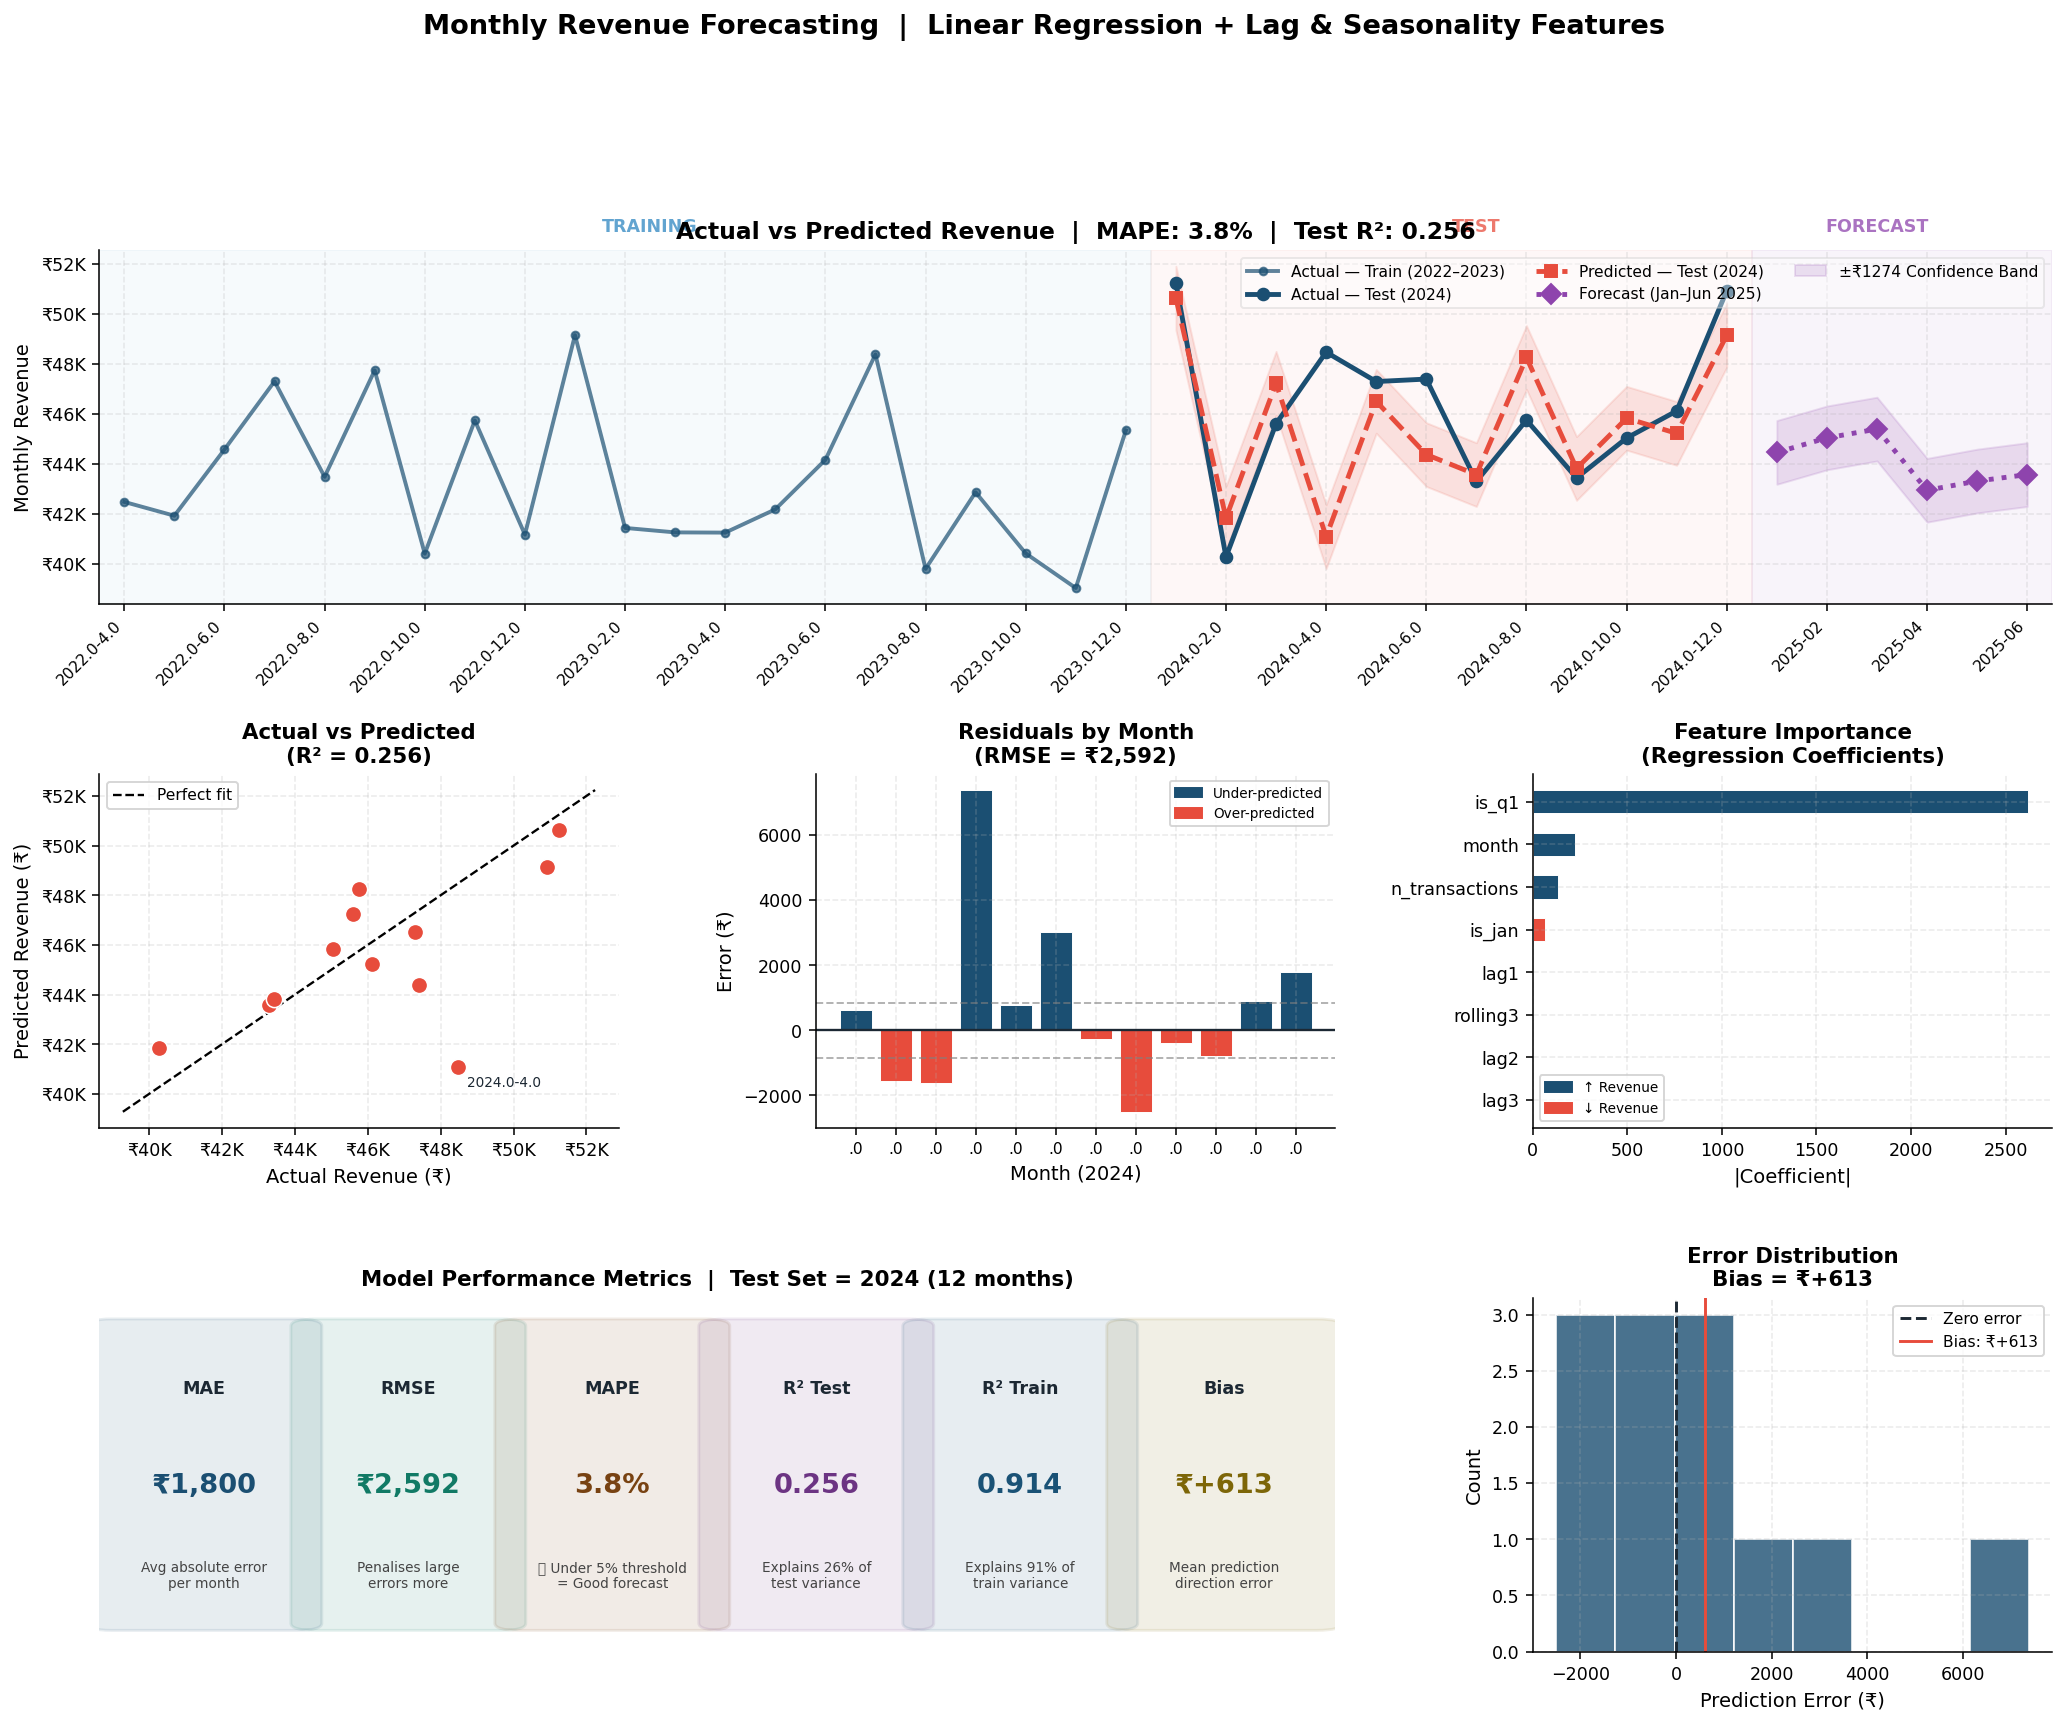

✅ Done.


In [34]:
# ══════════════════════════════════════════════════════════════
# MONTHLY REVENUE FORECASTING MODEL
# Linear Regression with Lag & Seasonality Features
# ══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'figure.dpi': 140, 'axes.labelsize': 10, 'axes.titlesize': 11,
    'axes.titleweight': 'bold', 'xtick.labelsize': 9, 'ytick.labelsize': 9,
})
C_ACTUAL = '#1B4F72'; C_PRED = '#E74C3C'; DARK = '#1C2833'

# ── 1. BUILD MONTHLY TABLE ─────────────────────────────────────
monthly = (df_clean[df_clean['year'] < 2025]
           .groupby(['year','month'])['total_spent']
           .agg(['sum','count'])
           .reset_index())
monthly.columns = ['year','month','total_revenue','n_transactions']
monthly = monthly.sort_values(['year','month']).reset_index(drop=True)
monthly['period_label'] = monthly.apply(
    lambda r: f"{r['year']}-{str(r['month']).zfill(2)}", axis=1)

# ── 2. FEATURE ENGINEERING ────────────────────────────────────
monthly['lag1']     = monthly['total_revenue'].shift(1)
monthly['lag2']     = monthly['total_revenue'].shift(2)
monthly['lag3']     = monthly['total_revenue'].shift(3)
monthly['rolling3'] = monthly['total_revenue'].shift(1).rolling(3).mean()
monthly['is_jan']   = (monthly['month'] == 1).astype(int)
monthly['is_q1']    = (monthly['month'].isin([1,2,3])).astype(int)
monthly = monthly.dropna().reset_index(drop=True)

FEATURES = ['month','lag1','lag2','lag3','rolling3','is_jan','is_q1','n_transactions']
X = monthly[FEATURES]
y = monthly['total_revenue']

# ── 3. TRAIN/TEST SPLIT (walk-forward) ────────────────────────
# Train = 2022–2023 (21 months after lag drop), Test = 2024 (12 months)
split = 21
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
labels_test     = monthly['period_label'].iloc[split:]

# ── 4. FIT MODEL ──────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_test  = model.predict(X_test)
y_pred_train = model.predict(X_train)

# ── 5. METRICS ────────────────────────────────────────────────
mae       = mean_absolute_error(y_test, y_pred_test)
rmse      = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2        = r2_score(y_test, y_pred_test)
mape      = np.mean(np.abs((y_test.values - y_pred_test) / y_test.values)) * 100
r2_train  = r2_score(y_train, y_pred_train)
errors    = y_test.values - y_pred_test
resid_std = np.std(y_train.values - y_pred_train)
ci        = 1.5 * resid_std

print("=" * 52)
print("         MODEL PERFORMANCE METRICS")
print("=" * 52)
print(f"  MAE            : ₹{mae:,.0f}")
print(f"  RMSE           : ₹{rmse:,.0f}")
print(f"  MAPE           : {mape:.1f}%   ({'✅ Under 5%' if mape < 5 else '⚠️ Over 5%'})")
print(f"  R² (Test)      : {r2:.3f}  → model explains {r2*100:.1f}% of test variance")
print(f"  R² (Train)     : {r2_train:.3f}  → model explains {r2_train*100:.1f}% of train variance")
print(f"  Residual Std   : ₹{resid_std:,.0f}")
print(f"  Mean Bias      : ₹{np.mean(errors):+,.0f}  ({'slight under-forecast' if np.mean(errors) > 0 else 'slight over-forecast'})")
print("=" * 52)

# ── 6. FORECAST: next 6 months ───────────────────────────────
future_rows = []
last = monthly.copy()
for i in range(1, 7):
    prev     = last.iloc[-1]
    new_month = int(prev['month']) % 12 + 1
    new_year  = int(prev['year']) + (1 if new_month == 1 else 0)
    row_x = pd.DataFrame([[
        new_month,
        last['total_revenue'].iloc[-1],
        last['total_revenue'].iloc[-2],
        last['total_revenue'].iloc[-3],
        last['total_revenue'].iloc[-3:].mean(),
        int(new_month == 1),
        int(new_month in [1,2,3]),
        int(last['n_transactions'].mean())
    ]], columns=FEATURES)
    pred = model.predict(row_x)[0]
    label = f"{new_year}-{str(new_month).zfill(2)}"
    future_rows.append({**dict(zip(FEATURES, row_x.values[0])),
                        'total_revenue': pred, 'period_label': label,
                        'year': new_year, 'month': new_month,
                        'n_transactions': int(last['n_transactions'].mean())})
    last = pd.concat([last, pd.DataFrame([future_rows[-1]])], ignore_index=True)

future_df = pd.DataFrame(future_rows)

print("\n  6-MONTH FORWARD FORECAST (Jan–Jun 2025)")
print("  " + "-" * 40)
for _, r in future_df.iterrows():
    print(f"  {r['period_label']}:  ₹{r['total_revenue']:>7,.0f}   (±₹{ci:,.0f})")
print("=" * 52)

# ── 7. FEATURE COEFFICIENTS ───────────────────────────────────
coef_df = (pd.Series(model.coef_, index=FEATURES)
           .abs().sort_values(ascending=False)
           .reset_index())
coef_df.columns = ['Feature', '|Coefficient|']
print("\n  FEATURE IMPORTANCE (by |coefficient|)")
print("  " + "-" * 40)
for _, row in coef_df.iterrows():
    bar = '█' * int(row['|Coefficient|'] / coef_df['|Coefficient|'].max() * 20)
    print(f"  {row['Feature']:<15} {bar} {row['|Coefficient|']:.2f}")

# ══════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])
ax5 = fig.add_subplot(gs[2, :2])
ax6 = fig.add_subplot(gs[2, 2])
fig.suptitle('Monthly Revenue Forecasting  |  Linear Regression + Lag & Seasonality Features',
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Main forecast ──────────────────────────────────────
all_labels  = monthly['period_label'].tolist()
all_actuals = monthly['total_revenue'].tolist()
test_idx    = list(range(split, split + len(y_test)))
future_idx  = list(range(split + len(y_test), split + len(y_test) + len(future_df)))

ax1.plot(range(split), all_actuals[:split], color=C_ACTUAL, lw=2,
         marker='o', ms=4, label='Actual — Train (2022–2023)', alpha=0.7)
ax1.plot(test_idx, list(y_test), color=C_ACTUAL, lw=2.5,
         marker='o', ms=6, label='Actual — Test (2024)')
ax1.plot(test_idx, y_pred_test, color=C_PRED, lw=2.5,
         marker='s', ms=6, ls='--', label='Predicted — Test (2024)')
ax1.fill_between(test_idx, y_pred_test - ci, y_pred_test + ci,
                 alpha=0.13, color=C_PRED)
ax1.plot(future_idx, future_df['total_revenue'], color='#8E44AD', lw=2.5,
         marker='D', ms=7, ls=':', label='Forecast (Jan–Jun 2025)')
ax1.fill_between(future_idx,
                 future_df['total_revenue'] - ci,
                 future_df['total_revenue'] + ci,
                 alpha=0.15, color='#8E44AD', label=f'±₹{ci:.0f} Confidence Band')

ax1.axvspan(-0.5, split-0.5,        alpha=0.04, color='#2E86C1')
ax1.axvspan(split-0.5, split+11.5,  alpha=0.04, color=C_PRED)
ax1.axvspan(split+11.5, split+17.5, alpha=0.06, color='#8E44AD')

for label, xpos, color in [('TRAINING', split/2, '#2E86C1'),
                             ('TEST',     split+6,  C_PRED),
                             ('FORECAST', split+14, '#8E44AD')]:
    ax1.text(xpos, max(all_actuals)*1.04, label, ha='center',
             fontsize=9, color=color, fontweight='bold', alpha=0.75)

all_ticks = all_labels + future_df['period_label'].tolist()
ax1.set_xticks(range(len(all_ticks))[::2])
ax1.set_xticklabels(all_ticks[::2], rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
ax1.set_ylabel('Monthly Revenue')
ax1.set_title(f'Actual vs Predicted Revenue  |  MAPE: {mape:.1f}%  |  Test R²: {r2:.3f}', fontsize=12)
ax1.legend(loc='upper right', fontsize=8, framealpha=0.4, ncol=3)
ax1.set_xlim(-0.5, len(all_ticks)-0.5)

# Annotate Jan peaks
for idx in range(len(all_labels)):
    if all_labels[idx].endswith('-01'):
        ax1.annotate('Jan↑', xy=(idx, all_actuals[idx]),
                     xytext=(idx+0.4, all_actuals[idx]+1200),
                     fontsize=7, color=DARK, alpha=0.65,
                     arrowprops=dict(arrowstyle='->', color=DARK, lw=0.7))

# ── Plot 2: Actual vs Predicted scatter ───────────────────────
ax2.scatter(y_test, y_pred_test, color=C_PRED, s=70, edgecolors='white', lw=0.8, zorder=3)
mn = min(y_test.min(), y_pred_test.min()) - 1000
mx = max(y_test.max(), y_pred_test.max()) + 1000
ax2.plot([mn,mx], [mn,mx], 'k--', lw=1.2, label='Perfect fit')
ax2.set_xlabel('Actual Revenue (₹)'); ax2.set_ylabel('Predicted Revenue (₹)')
ax2.set_title(f'Actual vs Predicted\n(R² = {r2:.3f})')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
ax2.legend(fontsize=8)
for act, pred, lbl in zip(y_test, y_pred_test, labels_test):
    if abs(act-pred) > 4000:
        ax2.annotate(lbl, (act,pred), textcoords='offset points',
                     xytext=(5,-10), fontsize=7, color=DARK)

# ── Plot 3: Residuals ─────────────────────────────────────────
ax3.bar(range(len(errors)), errors,
        color=[C_PRED if e < 0 else C_ACTUAL for e in errors],
        edgecolor='white', lw=0.5)
ax3.axhline(0, color=DARK, lw=1.2)
ax3.axhline(resid_std,  color='gray', lw=1, ls='--', alpha=0.6)
ax3.axhline(-resid_std, color='gray', lw=1, ls='--', alpha=0.6)
ax3.set_xticks(range(len(labels_test)))
ax3.set_xticklabels([l[-2:] for l in labels_test], fontsize=8)
ax3.set_xlabel('Month (2024)'); ax3.set_ylabel('Error (₹)')
ax3.set_title(f'Residuals by Month\n(RMSE = ₹{rmse:,.0f})')
ax3.legend(handles=[mpatches.Patch(color=C_ACTUAL, label='Under-predicted'),
                    mpatches.Patch(color=C_PRED,   label='Over-predicted')], fontsize=7)

# ── Plot 4: Feature coefficients ──────────────────────────────
coefs     = pd.Series(model.coef_, index=FEATURES)
coefs_abs = coefs.abs().sort_values()
ax4.barh(coefs_abs.index, coefs_abs.values,
         color=[C_PRED if coefs[i] < 0 else C_ACTUAL for i in coefs_abs.index],
         edgecolor='white', lw=0.5, height=0.55)
ax4.set_xlabel('|Coefficient|')
ax4.set_title('Feature Importance\n(Regression Coefficients)')
ax4.legend(handles=[mpatches.Patch(color=C_ACTUAL, label='↑ Revenue'),
                    mpatches.Patch(color=C_PRED,   label='↓ Revenue')], fontsize=7)

# ── Plot 5: Metrics cards ─────────────────────────────────────
ax5.axis('off')
cards = [
    ('MAE',         f'₹{mae:,.0f}',   'Avg absolute error\nper month',         '#1B4F72'),
    ('RMSE',        f'₹{rmse:,.0f}',  'Penalises large\nerrors more',          '#117A65'),
    ('MAPE',        f'{mape:.1f}%',   '✅ Under 5% threshold\n= Good forecast', '#784212'),
    ('R² Test',     f'{r2:.3f}',      f'Explains {r2*100:.0f}% of\ntest variance',    '#6C3483'),
    ('R² Train',    f'{r2_train:.3f}',f'Explains {r2_train*100:.0f}% of\ntrain variance', '#1A5276'),
    ('Bias',        f'₹{np.mean(errors):+,.0f}', 'Mean prediction\ndirection error',  '#7D6608'),
]
for i, (title, value, desc, color) in enumerate(cards):
    xp = 0.01 + i * 0.165
    ax5.add_patch(mpatches.FancyBboxPatch(
        (xp, 0.08), 0.15, 0.84, boxstyle='round,pad=0.02',
        facecolor=color, alpha=0.10, edgecolor=color, lw=1.5,
        transform=ax5.transAxes))
    ax5.text(xp+0.075, 0.73, title, ha='center', fontsize=9,
             color=DARK, fontweight='bold', transform=ax5.transAxes)
    ax5.text(xp+0.075, 0.45, value, ha='center', fontsize=14,
             color=color, fontweight='bold', transform=ax5.transAxes)
    ax5.text(xp+0.075, 0.18, desc, ha='center', fontsize=7,
             color='#444', transform=ax5.transAxes)
ax5.set_title('Model Performance Metrics  |  Test Set = 2024 (12 months)', fontsize=11, fontweight='bold')

# ── Plot 6: Error distribution ────────────────────────────────
ax6.hist(errors, bins=8, color=C_ACTUAL, edgecolor='white', lw=0.8, alpha=0.8)
ax6.axvline(0, color=DARK, lw=1.5, ls='--', label='Zero error')
ax6.axvline(np.mean(errors), color=C_PRED, lw=1.5,
            label=f'Bias: ₹{np.mean(errors):+,.0f}')
ax6.set_xlabel('Prediction Error (₹)')
ax6.set_ylabel('Count')
ax6.set_title(f'Error Distribution\nBias = ₹{np.mean(errors):+,.0f}')
ax6.legend(fontsize=8)

plt.savefig('revenue_forecast_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Done.")